In [1]:
from pipeline_functions import *
import torch
import snntorch.spikeplot as splt
import matplotlib.pyplot as plt

Raw data shape: (32, 117120)
(8, 307, 1800)


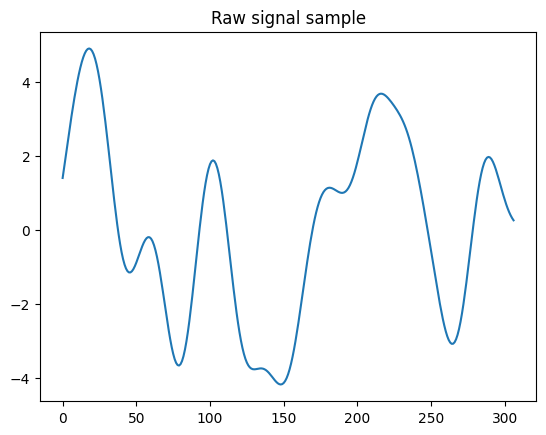

X shape: (1800, 8, 307)
Shape after feature extraction: (360, 8, 61)


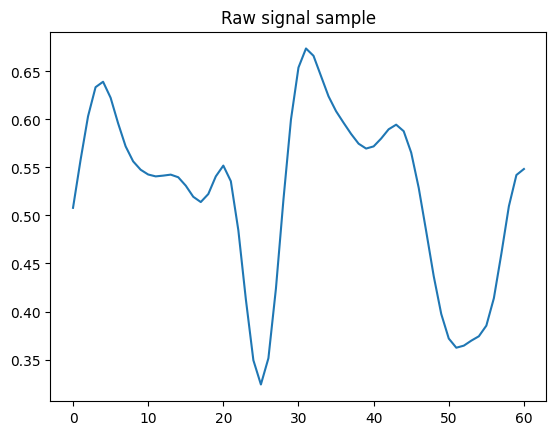

(360, 61, 8)


In [2]:
file_path = f"C:/Users/crims/Desktop/Senior Design Code/datasets/Won2022_BIDS/.mat_files/s01.mat"
# preprocessing
X, y = fn_preprocess.preprocess_testing(file_path, use_training=True)
print(X.shape)

plt.plot(X[0, :, 0])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()

# feature extraction
X_fe, y_fe = fn_feature_extraction.extractFeatures(X, y, k=5, factor=5)

plt.plot(X_fe[0, 0, :])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()

X_encoded = delta_encoding.delta_encode(X_fe, threshold=0.012) #spike encoding to implement
print(X_encoded.shape)


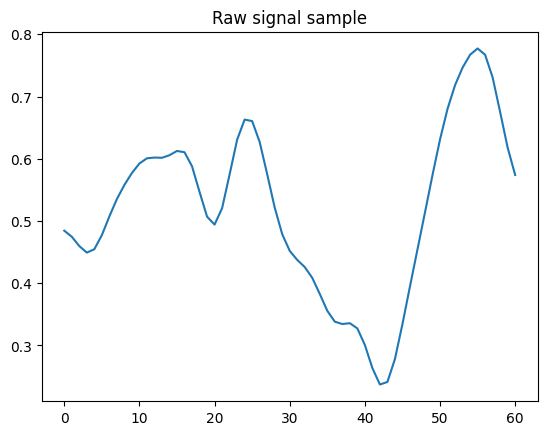

(360, 61, 8)
[ 1  0 -1  0  0  1  1  1  1  1  1  0  0  0  0  0  0 -1 -1 -1 -1  1  1  1
  1  0 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1  0  0  0 -1 -1 -1  0  1  1  1  1
  1  1  1  1  1  1  1  0  0 -1 -1 -1 -1]


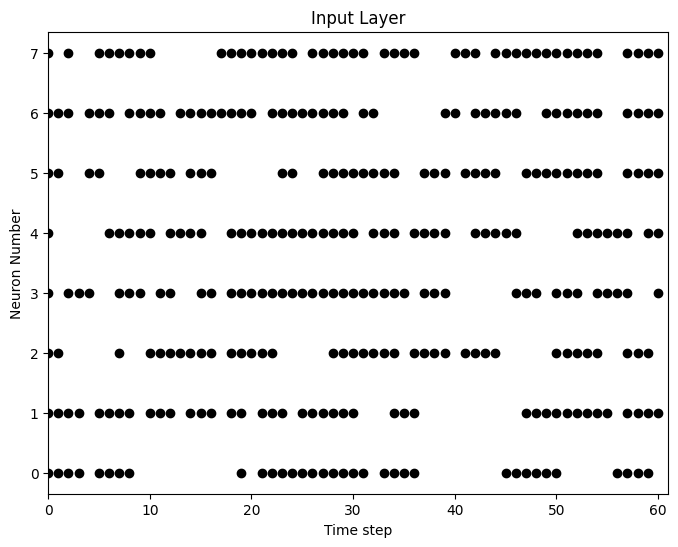

In [11]:
plt.plot(X_fe[0, 7, :])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()

X_encoded = delta_encoding.delta_encode(X_fe, threshold=0.012) #spike encoding to implement
print(X_encoded.shape)
# Create fig, ax
fig = plt.figure(facecolor="w", figsize=(8, 6))
ax = fig.add_subplot(111)

print(X_encoded[0, :, 7])
trial_spikes = torch.from_numpy(X_encoded[0, :, :])

# Raster plot of delta converted data
splt.raster(trial_spikes, ax, c="black")

plt.title("Input Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.xlim(0, X_encoded.shape[1])
plt.show()


In [8]:

# create module
snn = SNNModule.createSNN(8, [256, 128], betas=[0.95, 0.95, 0.95], thresholds=[1, 1, 1])

# load in weights
# weights = torch.load('snn_weights.pth', weights_only=True)
# snn.load_state_dict(weights)

snn.eval()

# separate X into individual character signals instead of one big dataset
for i in range(len(X_encoded)//12//3):
    start_idx = i*12*(15//5)
    end_idx = start_idx + 12*(15//5)
    X_char = X_encoded[start_idx:end_idx]
    X_char = torch.from_numpy(X_char).float()
    y_char = y_fe[start_idx:end_idx]

    # print(X_char.shape)
    # print(X_char.dtype)
    # print(y_char.shape)

    #get results of model
    with torch.no_grad():
        spk_results, mem_results = snn(X_char, batch_first=True)

    # select character based on results
    letter, row_idx, col_idx, row_total, col_total = Characterselection.p300_speller_cycle(spk_results)

    print(letter)

D
A
G
6
D
H
7
W
U
A
